# Affine Lensing


In [44]:
import batsim
import galsim
import numpy as np
import matplotlib.pyplot as plt

from time import time

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['cmr10']
plt.rcParams['mathtext.fontset'] ='cm'
plt.rcParams['figure.facecolor'] = 'white'
plt.rc('axes', unicode_minus=False)
plt.rc('axes.formatter', use_mathtext=True)

For completeness and validation purposes, we provide an affine lensing transform object within BATSim. We will use this to demonstrate what transform objects are and how they are used by ``batsim.simulate_galaxy()``.

We start by defining our transform object. Note that this implementation is equivalent to ``galsim.Lens()`` as it includes lensing convergence and magnification, unlike ``galsim.Shear()``, which uses the reduced shear formalism.

In [45]:
# Define shear components and convergence. We use exagerated values for clearly
# visible effects.
gamma1 = 0.2
gamma2 = -0.12
kappa = 0.08

# Instantiate LensTransform
lens_transform = batsim.LensTransform(
    gamma1=gamma1,
    gamma2=gamma2,
    kappa=kappa
)

# Every transfrom class has a transform method which implements the INVERSE
# coordinate transform. The renderer then samples flux from the inverse transformed 
# coordinates to the original coordinate points, resulting in an image which appears 
# to have been sheared according to the forward transform.
coords = np.array([[1,2],[2,1]])
coords_transformed = lens_transform.transform(coords)
print("Transformed coordinates:") 
print(coords_transformed)

# Extract the INVERSE lensing matrix from the transform object
lens_mat = lens_transform.lens_mat
print("Inverse Lensing Matrix:")
print(lens_mat)

Transformed coordinates:
[[0.96 1.56]
 [2.36 1.36]]
Inverse Lensing Matrix:
[[0.72 0.12]
 [0.12 1.12]]


Now we have seen a little of how the transform object functions, let's actually apply it to a Galsim object.

Rendering lensed and convolved galaxy took 0.143703 seconds


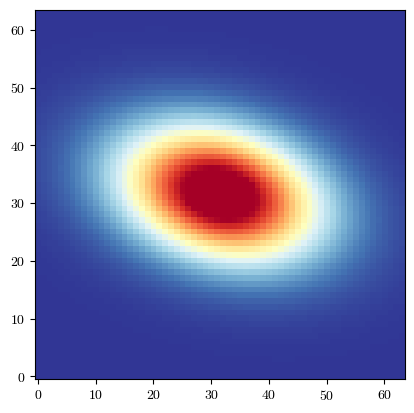

In [ ]:
# Define our galaxy profile as a GSObject
gal = galsim.Sersic(half_light_radius=1.3, n=1).withFlux(40)
psf = galsim.Moffat(beta=3.5, fwhm=0.7)

# Define image parameters
ngrid = 64 # number of pixels along x and y. Total pixels is n_grid*n_grid
pix_scale = 0.2 # number of arcseconds each pixels should cover

# Call BATSim's renderer, returns np.array
start = time()
batsim_image = batsim.simulate_galaxy(
    gal_obj=gal, # pass the GSObject profile
    psf_obj=psf,
    transform_obj=lens_transform,
    ngrid=ngrid, # If None, BATSim chooses a sensible size based on scale
    scale=pix_scale, # pixel scale of the FINAL output image
)
end = time()
print(f"Rendering lensed and convolved galaxy took {end-start:3f} seconds")

# Call BATSim's plotting utility to get a nicely normalised image
fig = batsim.pltutil.make_plot_image(batsim_image)

The class based approach to transforms is inspired by Galsim's ``GSObjects``, which provide a unified way to represent a wide range of surface brightness profiles. It also makes it easier for users to define custom transforms which can then be directly passed to the renderer, but we will look at that in a later example...

As a last step, let's have a quick look at how our BATSim sheared and rendered galaxy compares to one simulated entirely within Galsim.

Rendering lensed and convolved galaxy took 0.001887 seconds


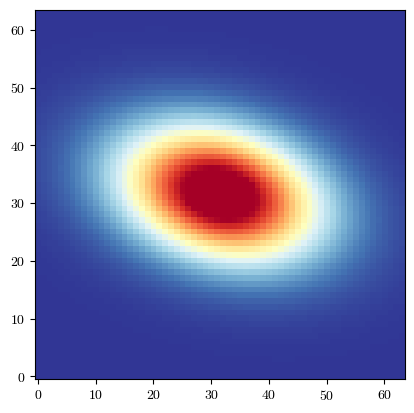

In [ ]:
# Convert gamma1, gamma2, and kappa to g1, g2, and mu for Galsim
g1 = gamma1 / (1.0 - kappa)
g2 = gamma2 / (1.0 - kappa)
mu = 1.0 / ((1.0 - kappa) ** 2 - gamma1**2 - gamma2**2)

# Use galsim to lens un-convolved galaxy
gal_lensed = gal.lens(g1, g2, mu)

# Convolve lensed galaxy with PSF
gal_conv = galsim.Convolve([gal_lensed, psf])

# Draw and time
start = time()
galsim_image = gal_conv.drawImage(nx=ngrid, ny=ngrid, scale=pix_scale).array
end = time()
print(f"Rendering lensed and convolved galaxy took {end-start:3f} seconds")

# Call BATSim's plotting utility to get a nicely normalised image
fig = batsim.pltutil.make_plot_image(galsim_image)

In [48]:
# Look at residuals between images
residual = galsim_image - batsim_image
print(f"GalSim flux: {galsim_image.sum():.8f}")
print(f"BATSim flux:    {batsim_image.sum():.8f}")
print(f"Max abs residual: {abs(residual).max():.3e}")

perc_residual = 100 * abs(residual).max() / galsim_image.max()
print(f"Max abs residual as % of max flux: {perc_residual:.3f}%")

GalSim flux: 50.13269424
BATSim flux:    50.13265991
Max abs residual: 2.593e-06
Max abs residual as % of max flux: 0.001%


BATSim and Galsim lensed images agree at the hundredth of a percent level, but evidently BATSim's renderer is much much slower. As mentioned previously, this is currently an unfortunate reality of the necessity to start our renderer in real-space and aggresively supersample.

Like in the previous no transform example, we suggest that for this type of work where only affine shear is required, the usual Galsim procedure is followed. BATSim should only be used in a production setting for non-affine shear rendering.